In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, interp1d

def load_and_prepare_data(file_path):
    df = pd.read_csv(file_path)
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df = df.dropna(subset=['Year'])
    df['Year'] = df['Year'].astype(int)
    
    df_melted = df.melt(id_vars=['Year'], var_name='Month', value_name='Value')
    df_melted['Month'] = df_melted['Month'].apply(lambda x: int(x.split('_')[1]))
    df_melted['Date'] = pd.to_datetime(df_melted[['Year', 'Month']].assign(DAY=1))
    
    na_indicators = [-99.90, -99.9, -99.99, -9.90, -999.0, 9999.00, -9, -9.99, 9.9, 9.99]
    df_melted['Value'] = df_melted['Value'].replace(na_indicators, pd.NA)
    df_melted = df_melted.dropna(subset=['Value'])
    
    df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')
    
    df_filtered = df_melted[(df_melted['Date'] >= '1980-01-01') & (df_melted['Date'] <= '2022-12-31')]
    df_filtered = df_filtered.sort_values(by='Date').reset_index(drop=True)
    
    return df_filtered

def interpolate_to_daily(df):
    date_range = pd.date_range(start='1980-01-01', end='2022-12-31', freq='D')
    df_daily = pd.DataFrame(date_range, columns=['Date'])
    
    # Convert datetime to ordinal for interpolation
    df['Date_ordinal'] = df['Date'].map(pd.Timestamp.toordinal)
    date_range_ordinal = date_range.map(pd.Timestamp.toordinal)
    
    # Use cubic splines for most of the data
    cs = CubicSpline(df['Date_ordinal'], df['Value'], extrapolate=False)
    df_daily['Value'] = cs(date_range_ordinal)
    
    # Use linear interpolation for the last few observations to stabilize the ends
    linear_end = interp1d(df['Date_ordinal'], df['Value'], kind='linear', fill_value='extrapolate')
    end_period = 30  # Define the number of days to apply linear interpolation at the end
    end_dates = date_range_ordinal[-end_period:]
    df_daily.loc[df_daily['Date'].isin(date_range[-end_period:]), 'Value'] = linear_end(end_dates)
    
    return df_daily

def standardize_series(series):
    return (series - series.mean()) / series.std()

# Main logic to load, prepare, interpolate, and plot the data
input_dir = "/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices"
indices_to_plot = [
    "Niño 3", "NAO", "Niño 1+2", "WHWP", "GMT", "ONI", "PNA", "NOI", "WP",
    "Niño 3.4", "Solar Flux", "AMO", "ESPI", "TSA", "Niño 4", "TNA", "SOI"
]

combined_data = pd.DataFrame()

for index_name in indices_to_plot:
    file_path = os.path.join(input_dir, f"{index_name}.csv")
    if os.path.exists(file_path):
        df = load_and_prepare_data(file_path)
        if not df[(df['Year'] == 2022) & (df['Month'] == 12)]['Value'].isna().any():
            df_daily = interpolate_to_daily(df)
            df_daily = df_daily.rename(columns={'Value': index_name})
            combined_data = pd.merge(combined_data, df_daily, on='Date', how='outer') if not combined_data.empty else df_daily
        else:
            print(f"December 2022 value is NA for {index_name}, skipping plot.")
    else:
        print(f"File not found: {file_path}")

# Standardize each index
for index_name in indices_to_plot:
    if index_name in combined_data.columns:
        combined_data[index_name] = standardize_series(combined_data[index_name])

# Save the standardized combined daily interpolated data
combined_data.to_csv(os.path.join(input_dir, "combined_indices_daily_standardized.csv"), index=False)


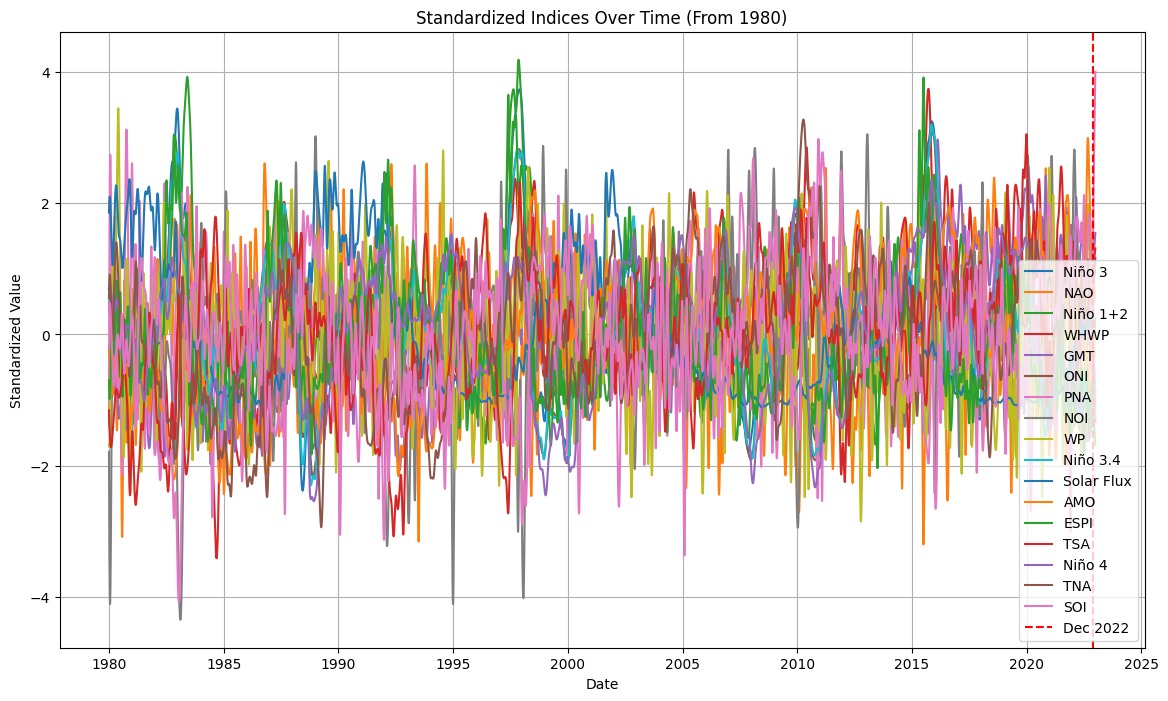

In [2]:

# Plotting combined standardized data for each index
plt.figure(figsize=(14, 8))
for index_name in indices_to_plot:
    if index_name in combined_data.columns:
        plt.plot(combined_data['Date'], combined_data[index_name], label=index_name)

plt.axvline(x=pd.Timestamp('2022-12-01'), color='red', linestyle='--', label='Dec 2022')
plt.title("Standardized Indices Over Time (From 1980)")
plt.xlabel("Date")
plt.ylabel("Standardized Value")
plt.legend()
plt.grid(True)
plt.show()


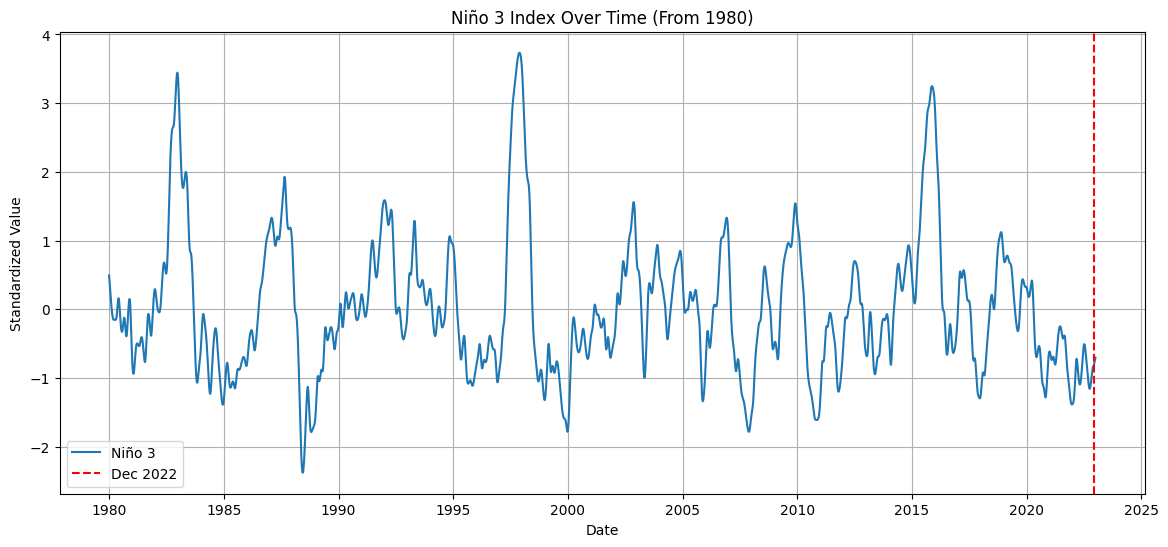

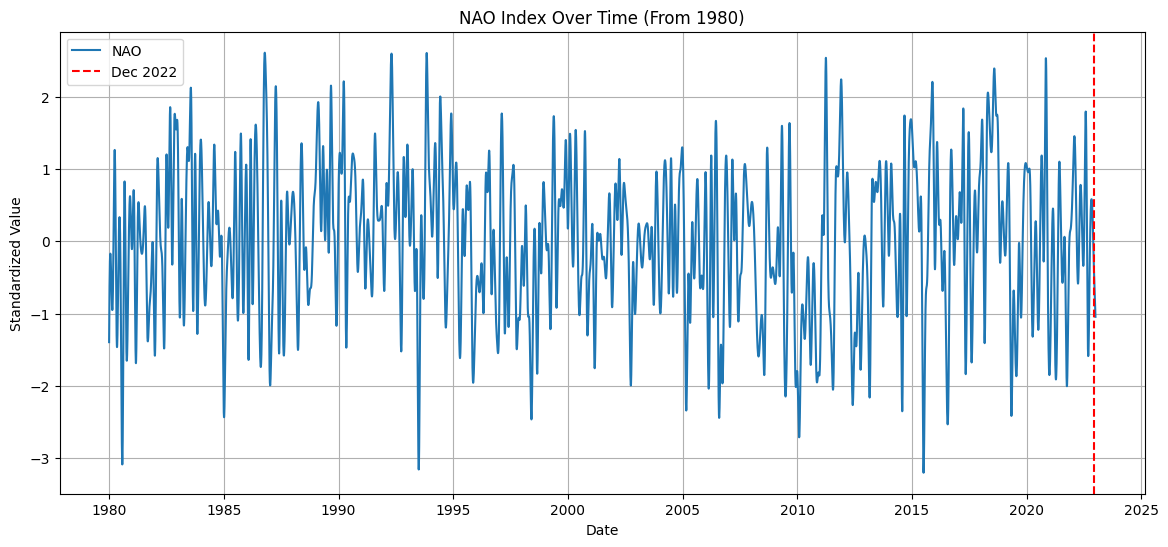

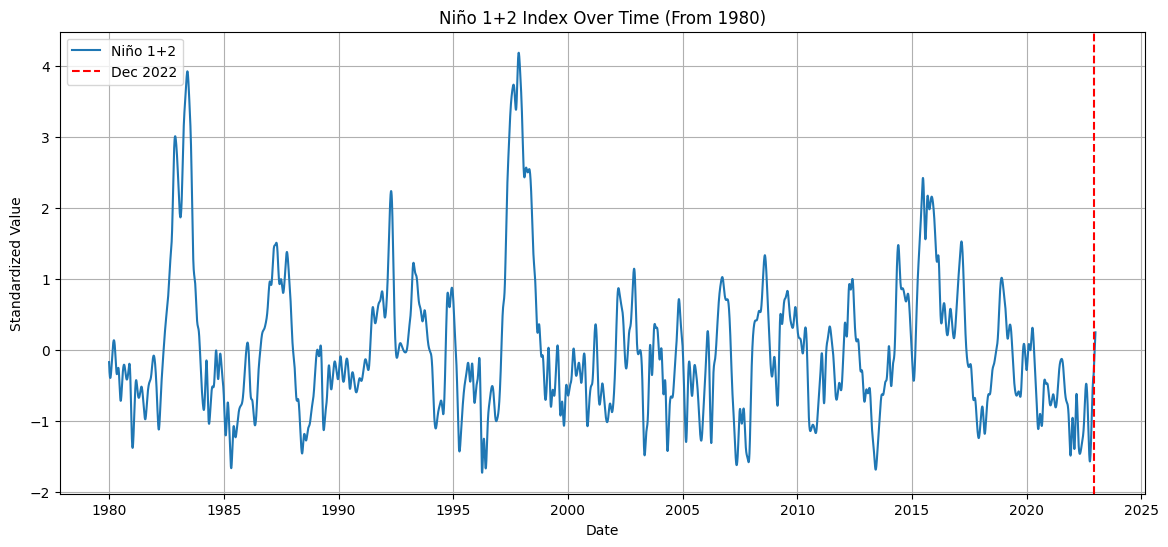

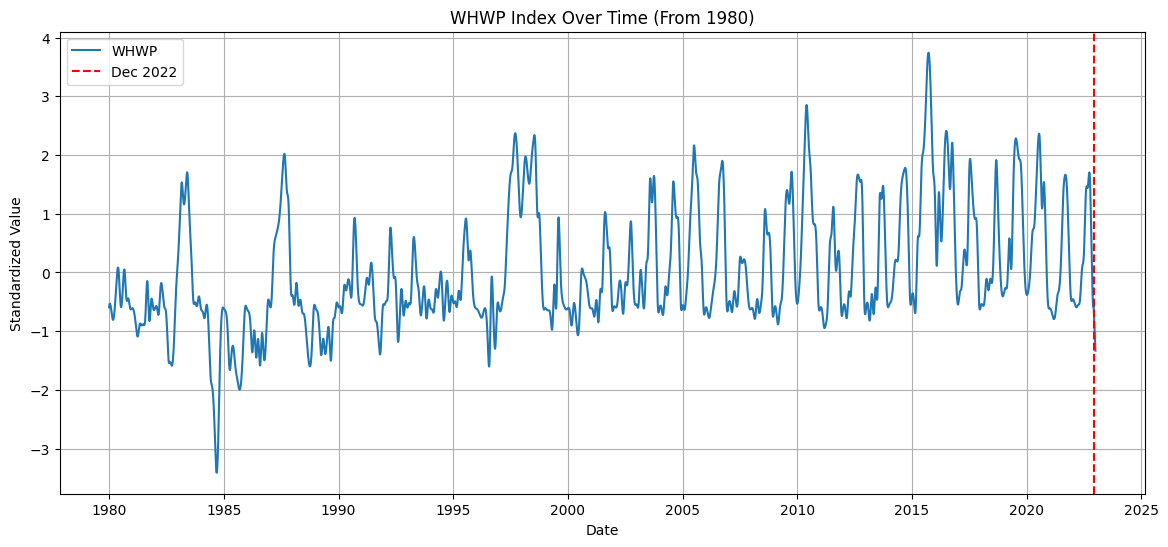

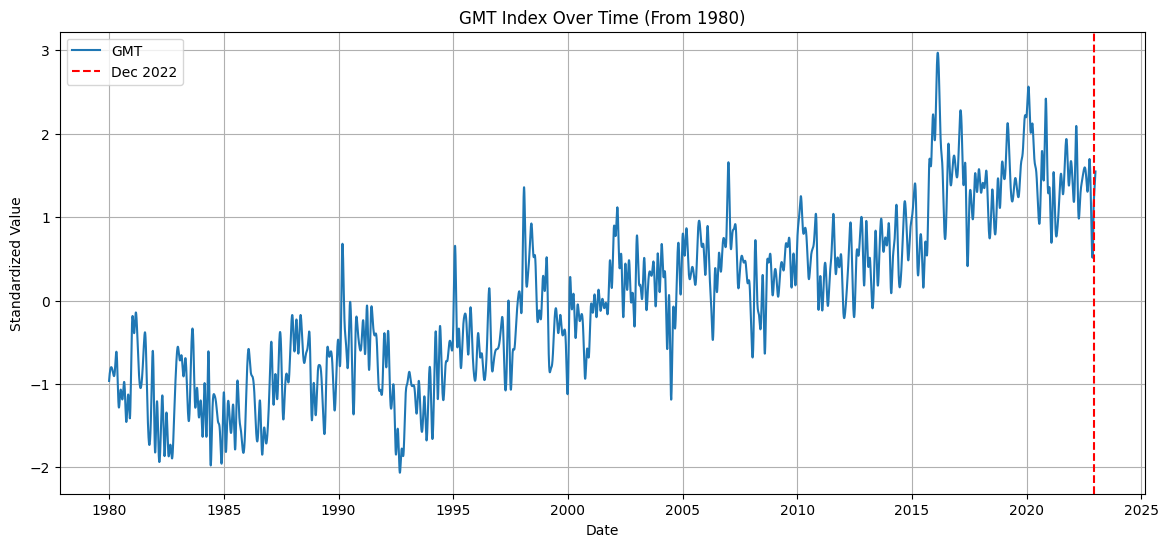

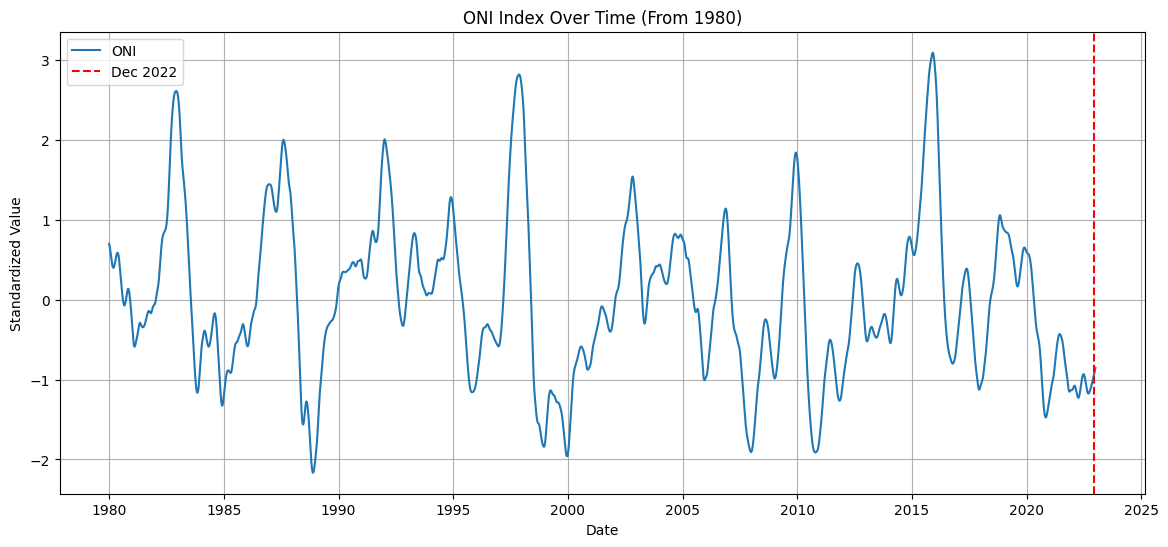

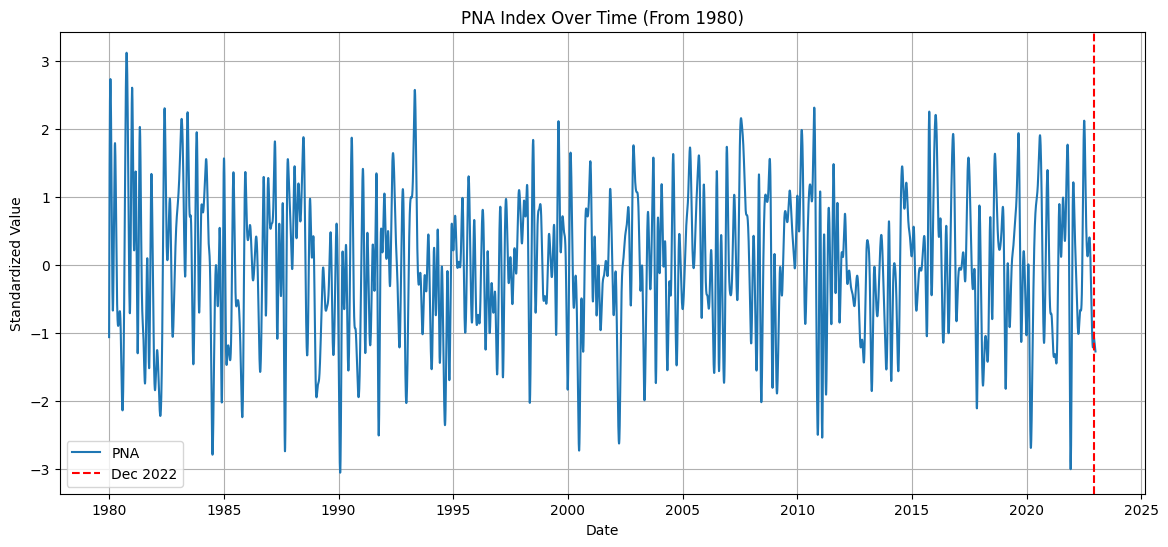

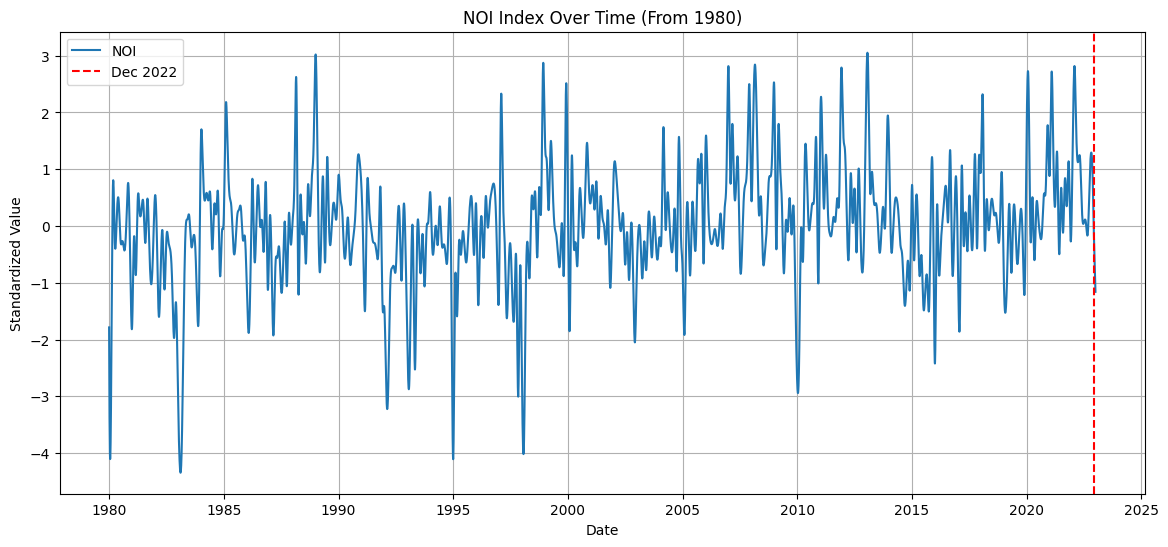

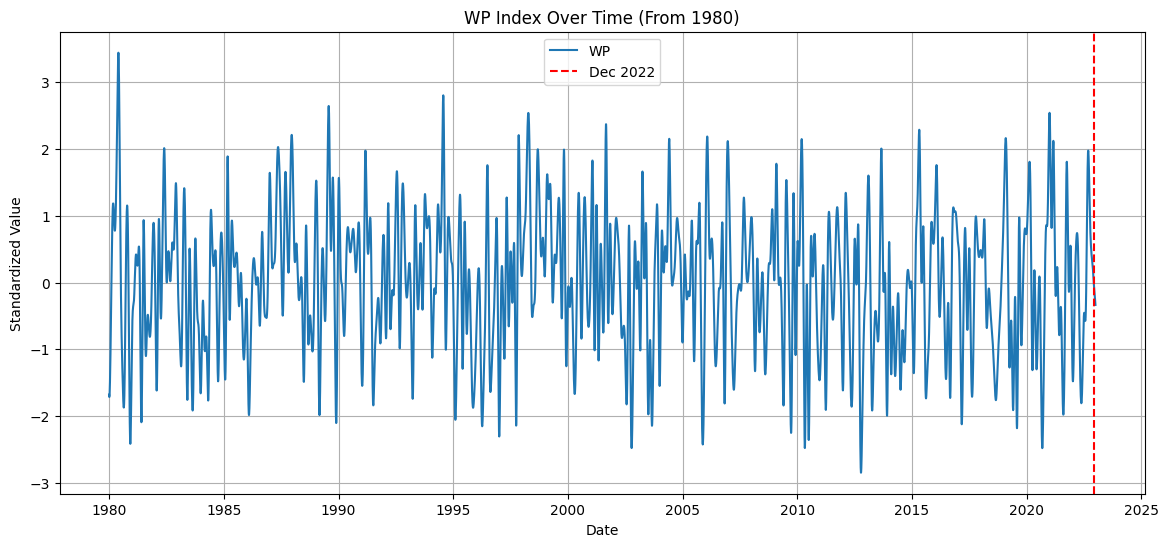

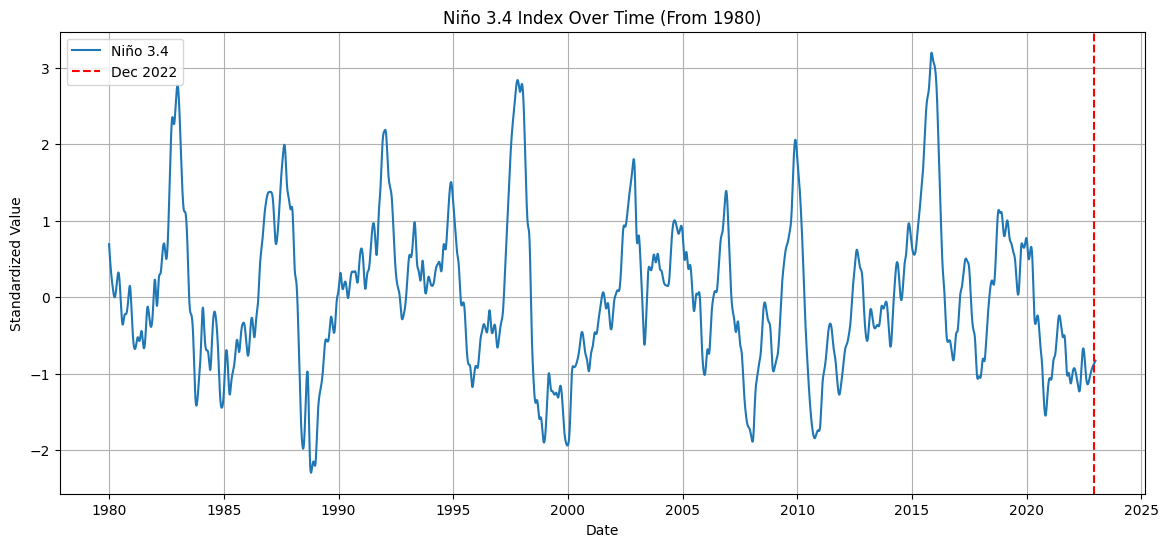

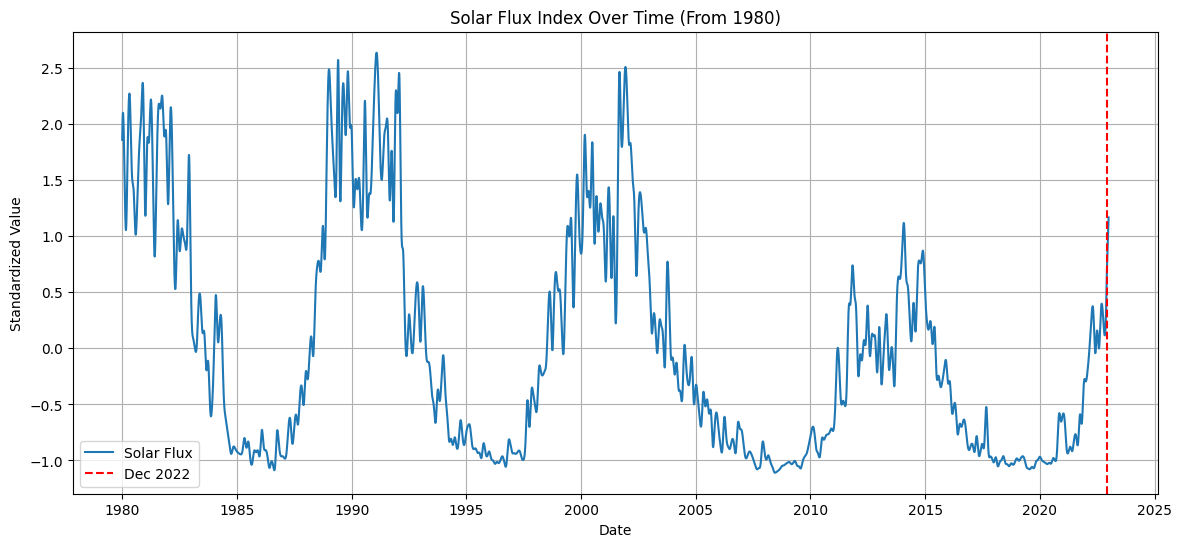

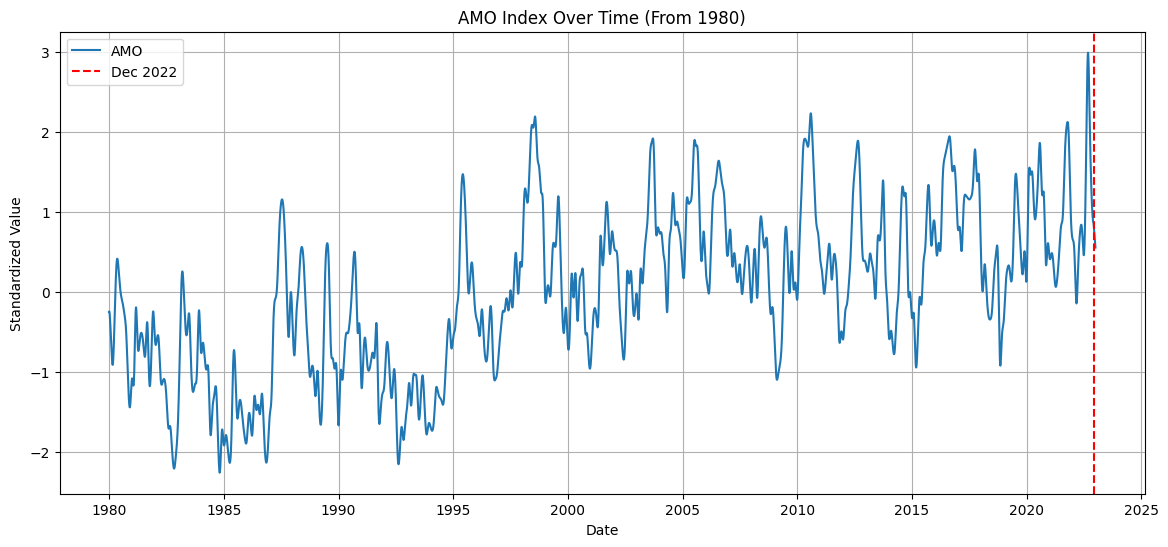

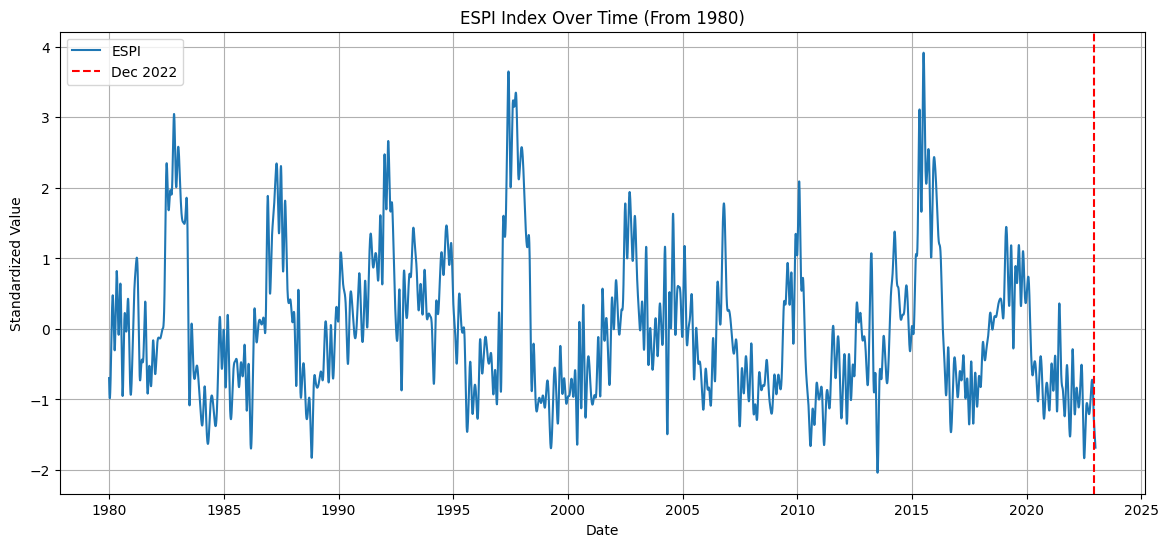

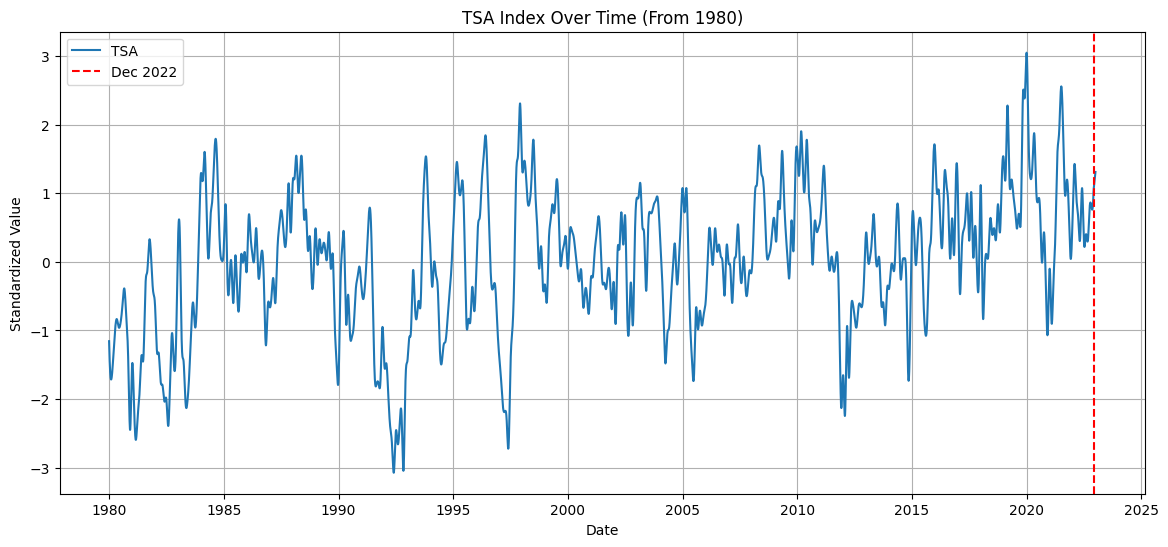

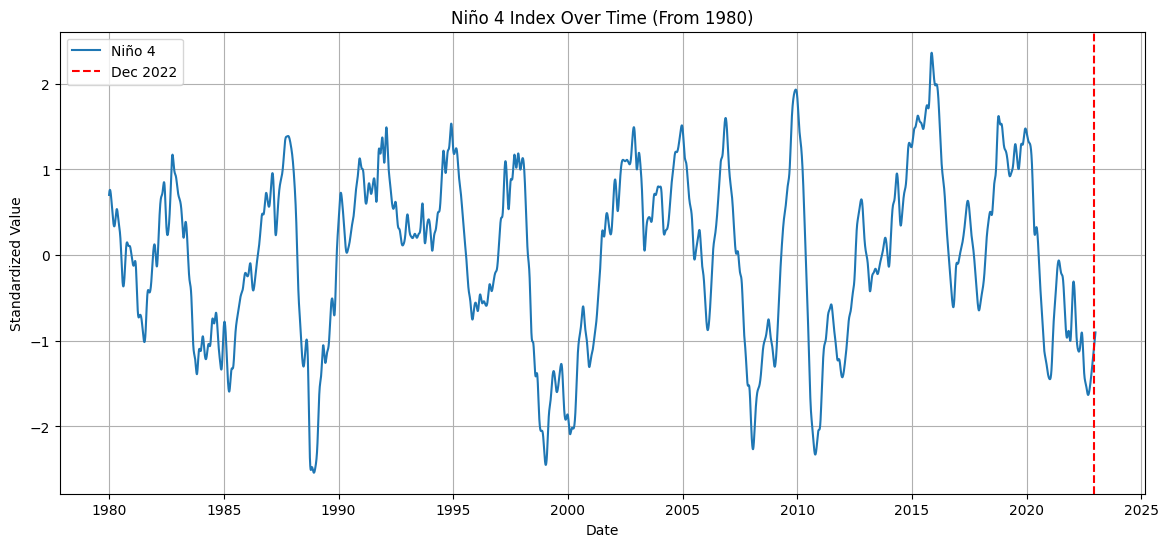

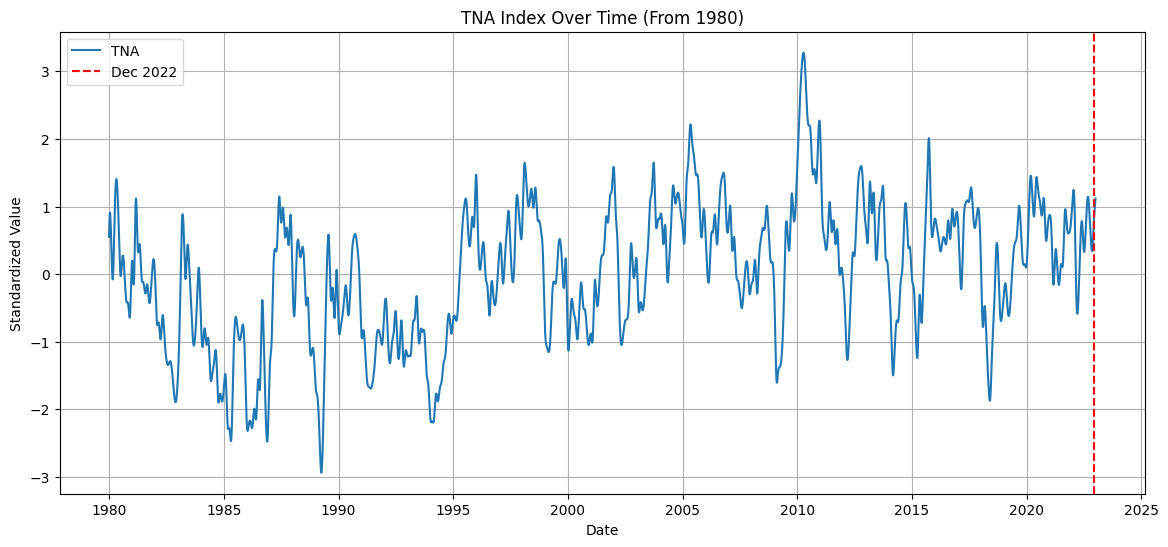

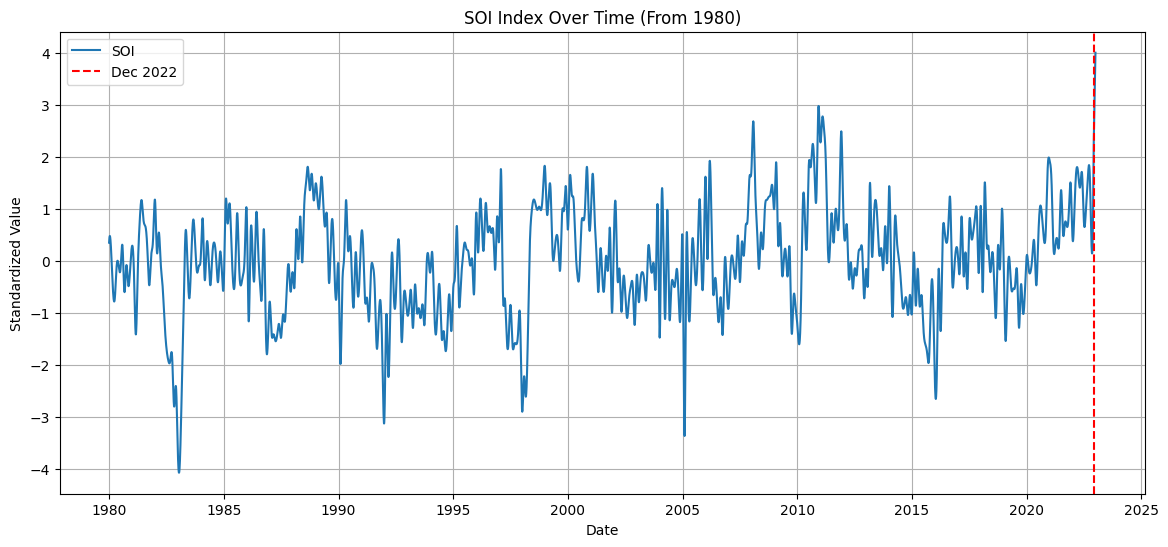

In [3]:

# Plotting each index individually
for index_name in indices_to_plot:
    if index_name in combined_data.columns:
        plt.figure(figsize=(14, 6))
        plt.plot(combined_data['Date'], combined_data[index_name], label=index_name)
        plt.axvline(x=pd.Timestamp('2022-12-01'), color='red', linestyle='--', label='Dec 2022')
        plt.title(f"{index_name} Index Over Time (From 1980)")
        plt.xlabel("Date")
        plt.ylabel("Standardized Value")
        plt.legend()
        plt.grid(True)
        plt.show()
input_dir = "/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices"

combined_data.to_csv(os.path.join(input_dir, "combined_indices_daily_standardized.csv"), index=False)


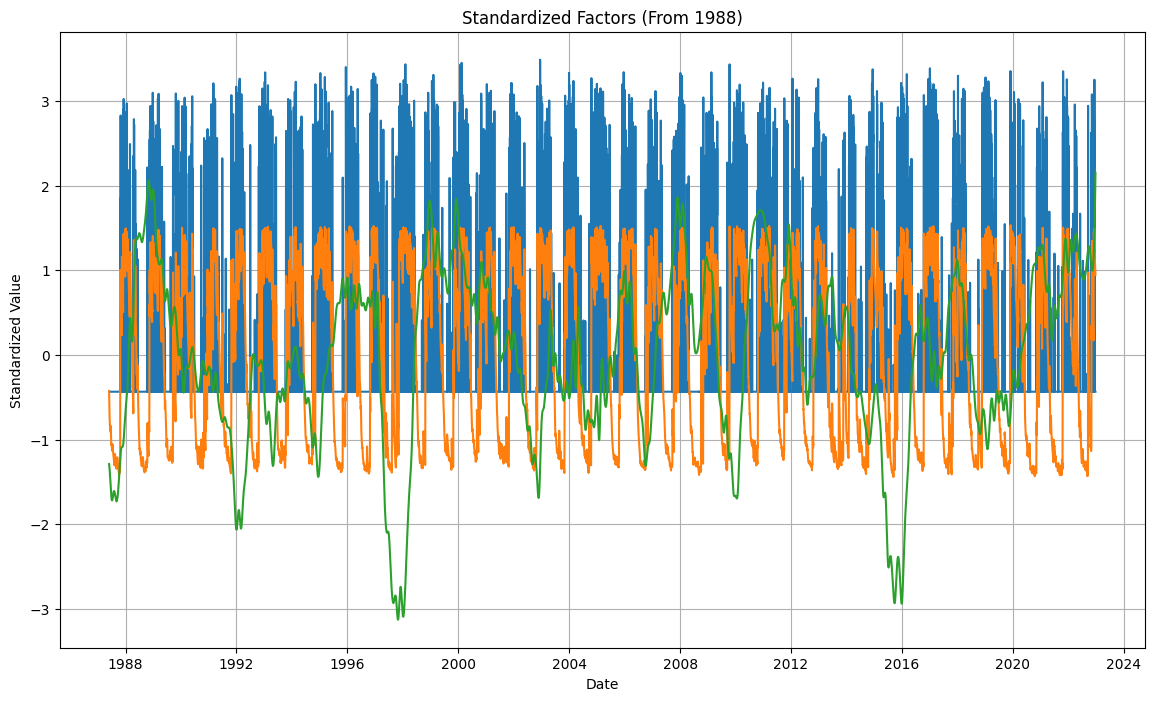

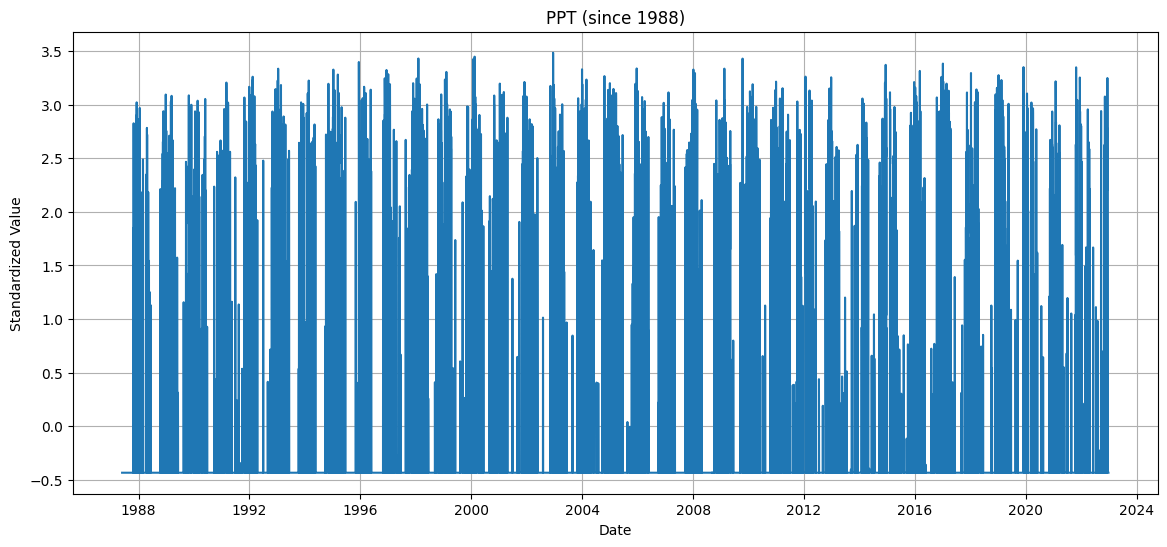

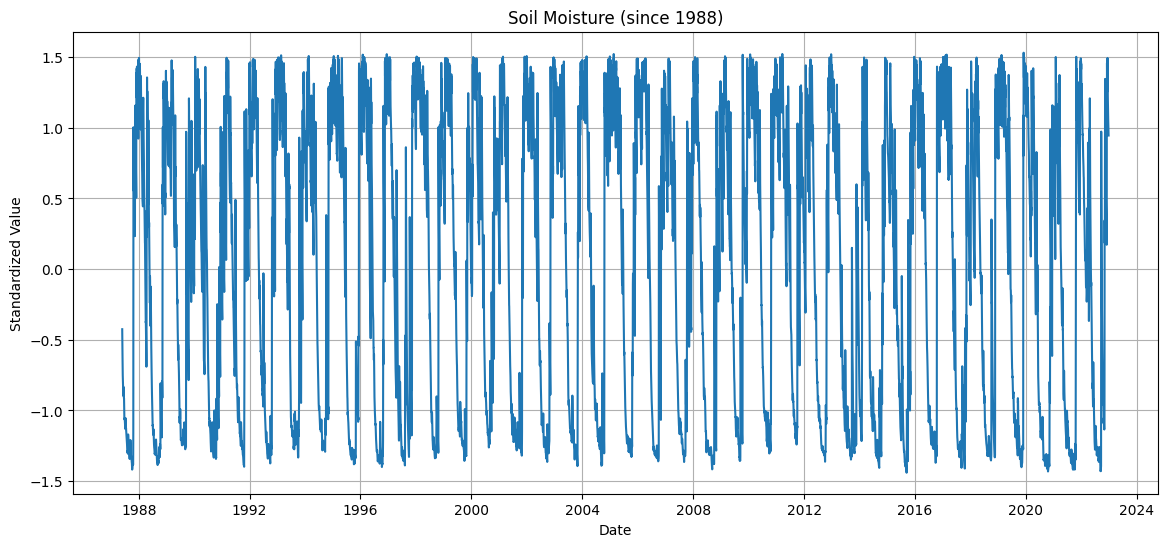

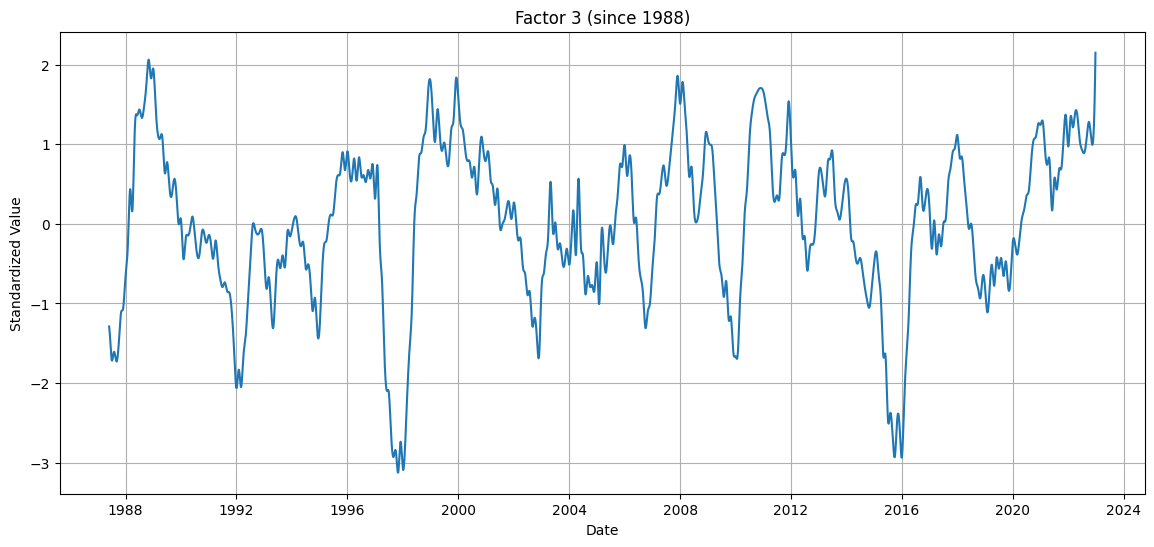

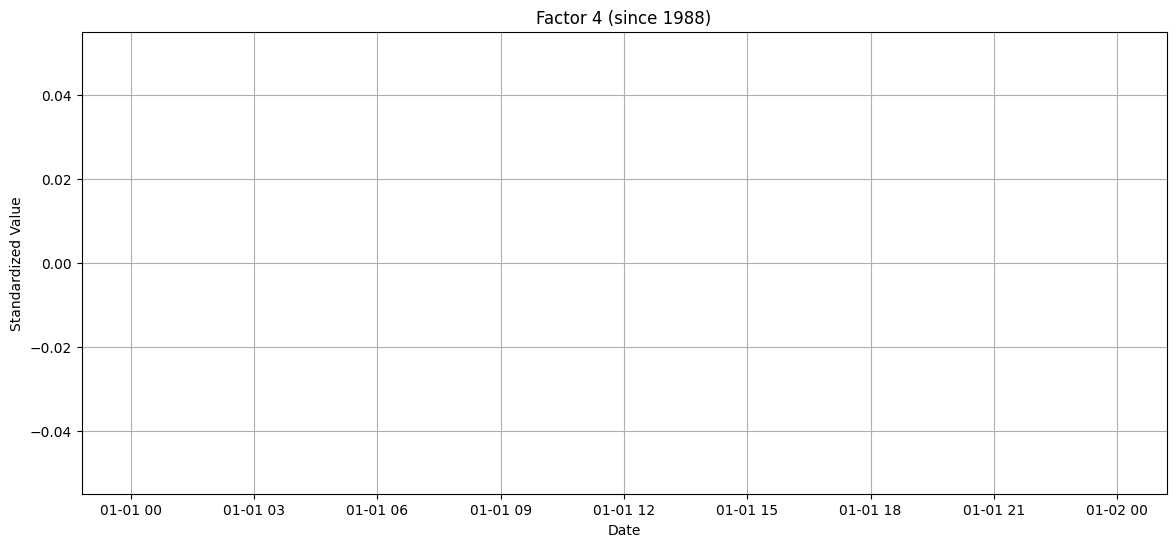

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
file_path = "/data/muscat_data/jaguir26/project1_ucsc_phd/factors.csv"
df_factors = pd.read_csv(file_path)

# Ensure that the first column is the timestamp and set it as the index
df_factors['Timestamp'] = pd.to_datetime(df_factors['Timestamp'])
df_factors.set_index('Timestamp', inplace=True)

# Rename the columns to Factor 1, Factor 2, ..., Factor 7
df_factors.columns = [f"Factor {i+1}" for i in range(df_factors.shape[1])]

# Standardize each factor (this is optional if your data isn't already standardized)
def standardize_series(series):
    return (series - series.mean()) / series.std()

df_factors = df_factors.apply(standardize_series)

# Save the standardized data (optional, in case you want to save it)
df_factors.to_csv("/data/muscat_data/jaguir26/project1_ucsc_phd/factors_standardized.csv")

# Plotting all factors together and save as .png
plt.figure(figsize=(14, 8))
for factor_name in df_factors.columns:
    plt.plot(df_factors.index, df_factors[factor_name], label=factor_name)

plt.title("Standardized Factors (From 1988)")
plt.xlabel("Date")
plt.ylabel("Standardized Value")
plt.grid(True)

# Save the combined plot
combined_plot_path = "/data/muscat_data/jaguir26/project1_ucsc_phd/standardized_factors_combined.png"
plt.savefig(combined_plot_path, dpi=300)  # Save with 300 dpi for high resolution
plt.show()

# Plotting each factor individually and save each as .png
for i, factor_name in enumerate(df_factors.columns, 1):
    plt.figure(figsize=(14, 6))
    plt.plot(df_factors.index, df_factors[factor_name])

    # Set the title based on the factor index
    if i == 1:
        plt.title("PPT (since 1988)")
    elif i == 2:
        plt.title("Soil Moisture (since 1988)")
    else:
        plt.title(f"{factor_name} (since 1988)")

    plt.xlabel("Date")
    plt.ylabel("Standardized Value")
    plt.grid(True)
    
    # Save each individual factor plot
    individual_plot_path = f"/data/muscat_data/jaguir26/project1_ucsc_phd/standardized_{factor_name.lower().replace(' ', '_')}.png"
    plt.savefig(individual_plot_path, dpi=300)  # Save with 300 dpi for high resolution
    plt.show()


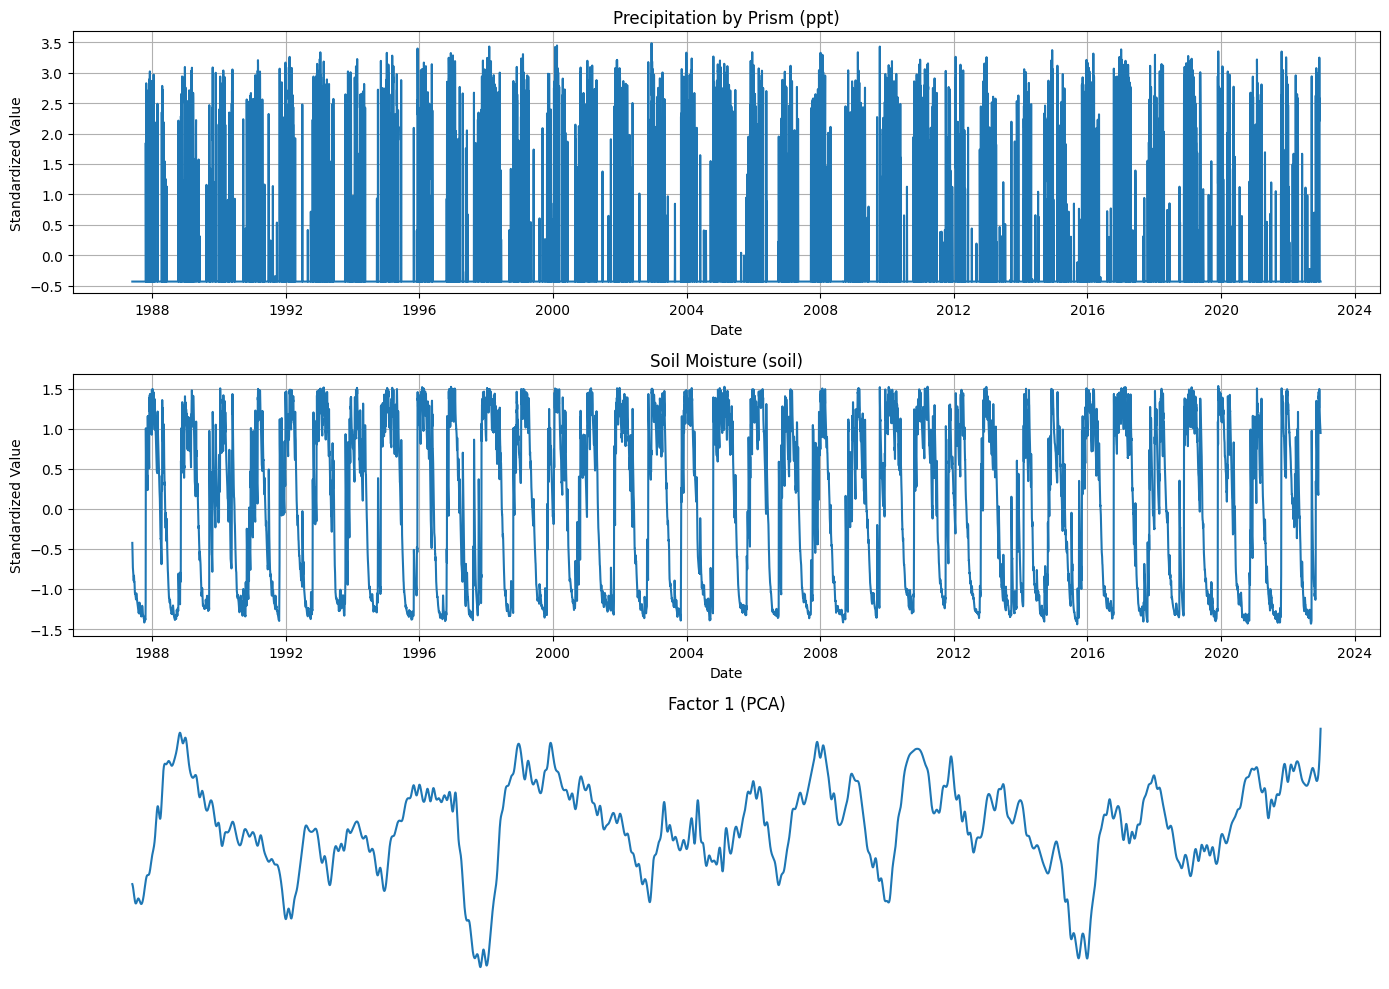

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
file_path = "/data/muscat_data/jaguir26/project1_ucsc_phd/factors.csv"
df_factors = pd.read_csv(file_path)

# Ensure that the first column is the timestamp and set it as the index
df_factors['Timestamp'] = pd.to_datetime(df_factors['Timestamp'])
df_factors.set_index('Timestamp', inplace=True)

# Rename the columns to Factor 1, Factor 2, and Factor 3
df_factors.columns = [f"Factor {i+1}" for i in range(df_factors.shape[1])]

# Standardize each factor (this is optional if your data isn't already standardized)
def standardize_series(series):
    return (series - series.mean()) / series.std()

df_factors = df_factors.apply(standardize_series)

# Create a 2x2 subplot matrix
fig, axs = plt.subplots(3, 1, figsize=(14, 10))  # 2 rows, 2 columns
axs = axs.flatten()  # Flatten the array of axes for easy indexing

# Plot each factor in its subplot with specific titles
titles = [
    "Precipitation by Prism (ppt)",  # Plot 1
    "Soil Moisture (soil)",         # Plot 2
    "Factor 1 (PCA)"                # Plot 3
]

for i, (factor_name, title) in enumerate(zip(df_factors.columns, titles)):
    axs[i].plot(df_factors.index, df_factors[factor_name])
    axs[i].set_title(title)
    axs[i].set_xlabel("Date")
    axs[i].set_ylabel("Standardized Value")
    axs[i].grid(True)

# Hide the 4th subplot since we only have 3 factors
axs[-1].axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the combined plot as a PNG file
combined_plot_path = "/data/muscat_data/jaguir26/project1_ucsc_phd/factors_2x2_subplot.png"
plt.savefig(combined_plot_path, dpi=300)

# Display the plot
plt.show()


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, interp1d

def load_and_prepare_data(file_path):
    df = pd.read_csv(file_path)
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
    df = df.dropna(subset=['Year'])
    df['Year'] = df['Year'].astype(int)
    
    df_melted = df.melt(id_vars=['Year'], var_name='Month', value_name='Value')
    df_melted['Month'] = df_melted['Month'].apply(lambda x: int(x.split('_')[1]))
    df_melted['Date'] = pd.to_datetime(df_melted[['Year', 'Month']].assign(DAY=1))
    
    na_indicators = [-99.90, -99.9, -99.99, -9.90, -999.0, 9999.00, -9, -9.99, 9.9, 9.99]
    df_melted['Value'] = df_melted['Value'].replace(na_indicators, pd.NA)
    df_melted = df_melted.dropna(subset=['Value'])
    
    df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')
    
    # Updated end date to include the full year of 2023
    df_filtered = df_melted[(df_melted['Date'] >= '1980-01-01') & (df_melted['Date'] <= '2023-12-31')]
    df_filtered = df_filtered.sort_values(by='Date').reset_index(drop=True)
    
    return df_filtered

def interpolate_to_daily(df):
    # Updated date range to extend to December 31, 2023
    date_range = pd.date_range(start='1980-01-01', end='2023-12-31', freq='D')
    df_daily = pd.DataFrame(date_range, columns=['Date'])
    
    # Convert datetime to ordinal for interpolation
    df['Date_ordinal'] = df['Date'].map(pd.Timestamp.toordinal)
    date_range_ordinal = date_range.map(pd.Timestamp.toordinal)
    
    # Use cubic splines for interpolation
    cs = CubicSpline(df['Date_ordinal'], df['Value'], extrapolate=False)
    df_daily['Value'] = cs(date_range_ordinal)
    
    # Use linear interpolation for the last few observations to stabilize the ends
    linear_end = interp1d(df['Date_ordinal'], df['Value'], kind='linear', fill_value='extrapolate')
    end_period = 30  # Number of days for linear interpolation at the end
    end_dates = date_range_ordinal[-end_period:]
    df_daily.loc[df_daily['Date'].isin(date_range[-end_period:]), 'Value'] = linear_end(end_dates)
    
    return df_daily

def standardize_series(series):
    return (series - series.mean()) / series.std()

# Main logic to load, prepare, interpolate, and plot the data
input_dir = "/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices"
indices_to_plot = [
    "Niño 3", "NAO", "Niño 1+2", "WHWP", "GMT", "ONI", "PNA", "NOI", "WP",
    "Niño 3.4", "Solar Flux", "AMO", "ESPI", "TSA", "Niño 4", "TNA", "SOI"
]

combined_data = pd.DataFrame()

for index_name in indices_to_plot:
    file_path = os.path.join(input_dir, f"{index_name}.csv")
    if os.path.exists(file_path):
        df = load_and_prepare_data(file_path)
        # Updated check: now ensuring December 2023 value is not missing.
        if not df[(df['Year'] == 2023) & (df['Month'] == 12)]['Value'].isna().any():
            df_daily = interpolate_to_daily(df)
            df_daily = df_daily.rename(columns={'Value': index_name})
            combined_data = pd.merge(combined_data, df_daily, on='Date', how='outer') if not combined_data.empty else df_daily
        else:
            print(f"December 2023 value is NA for {index_name}, skipping plot.")
    else:
        print(f"File not found: {file_path}")

# Standardize each index
for index_name in indices_to_plot:
    if index_name in combined_data.columns:
        combined_data[index_name] = standardize_series(combined_data[index_name])

# Save the standardized combined daily interpolated data
combined_csv_path = os.path.join(input_dir, "combined_indices_daily_standardized.csv")
combined_data.to_csv(combined_csv_path, index=False)
print(f"Standardized daily data saved to: {combined_csv_path}")


Standardized daily data saved to: /data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices/combined_indices_daily_standardized.csv


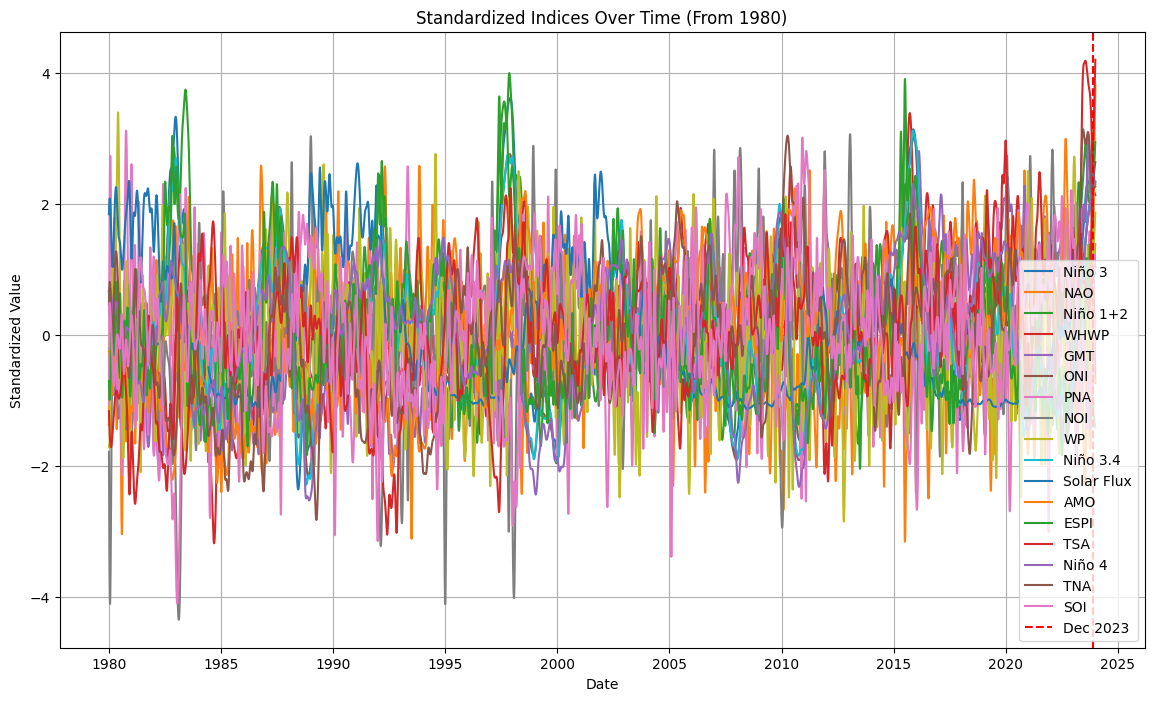

In [2]:

# Plotting combined standardized data for each index
plt.figure(figsize=(14, 8))
for index_name in indices_to_plot:
    if index_name in combined_data.columns:
        plt.plot(combined_data['Date'], combined_data[index_name], label=index_name)

plt.axvline(x=pd.Timestamp('2023-12-01'), color='red', linestyle='--', label='Dec 2023')
plt.title("Standardized Indices Over Time (From 1980)")
plt.xlabel("Date")
plt.ylabel("Standardized Value")
plt.legend()
plt.grid(True)
plt.show()


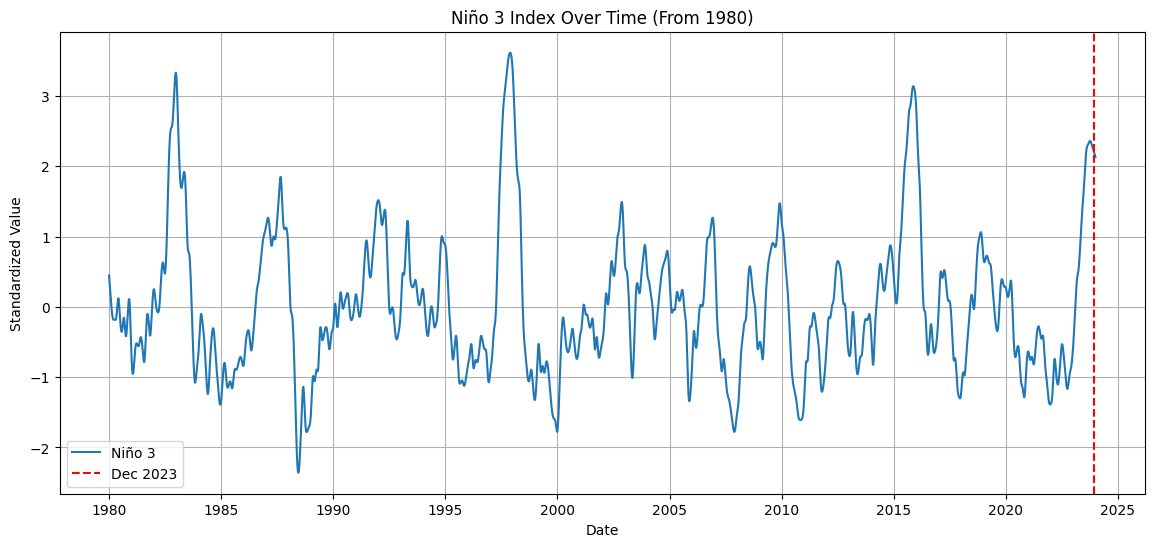

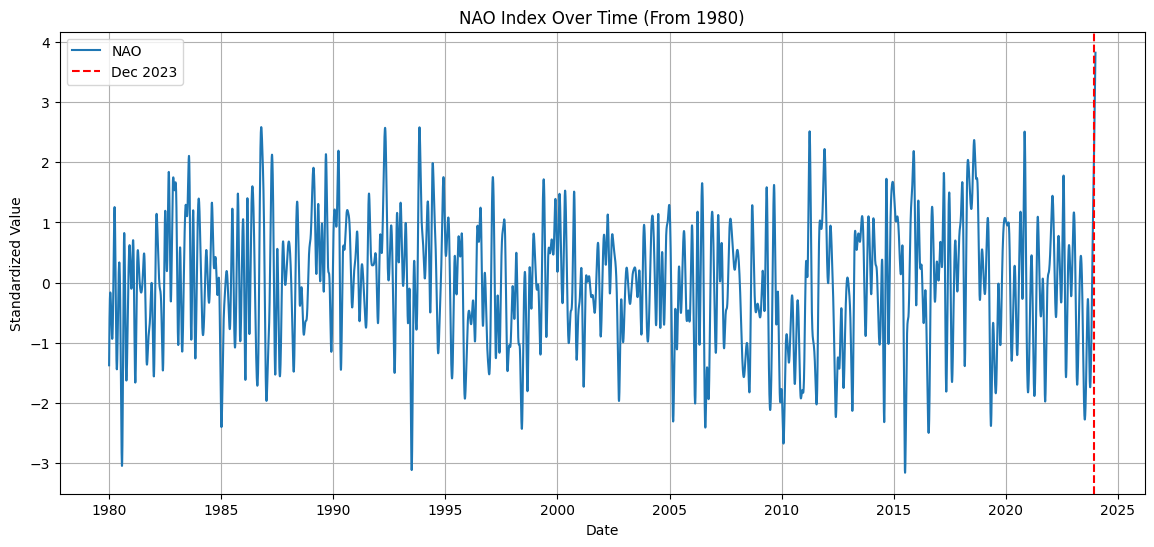

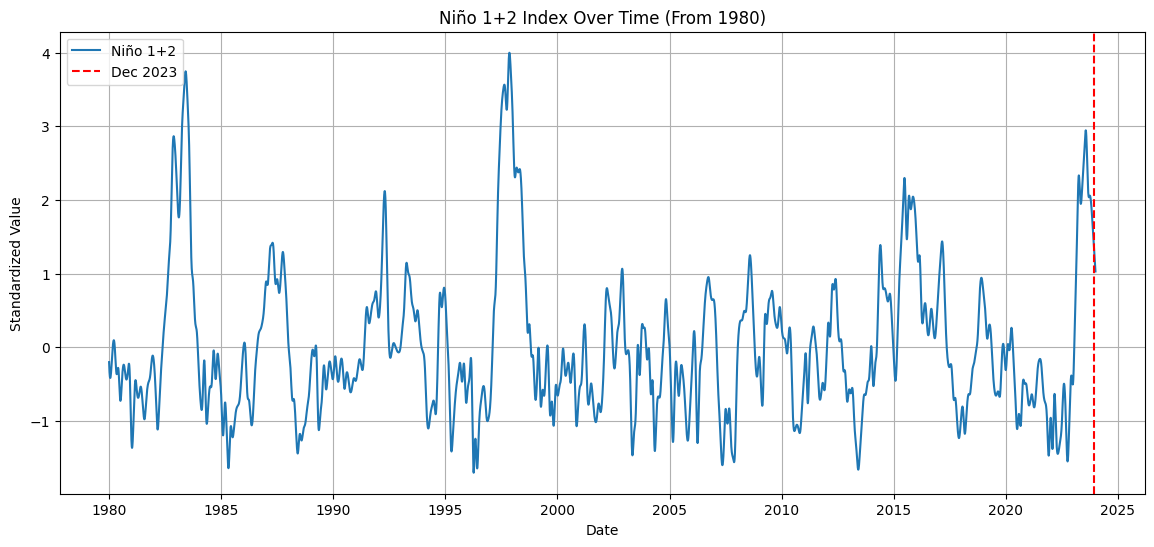

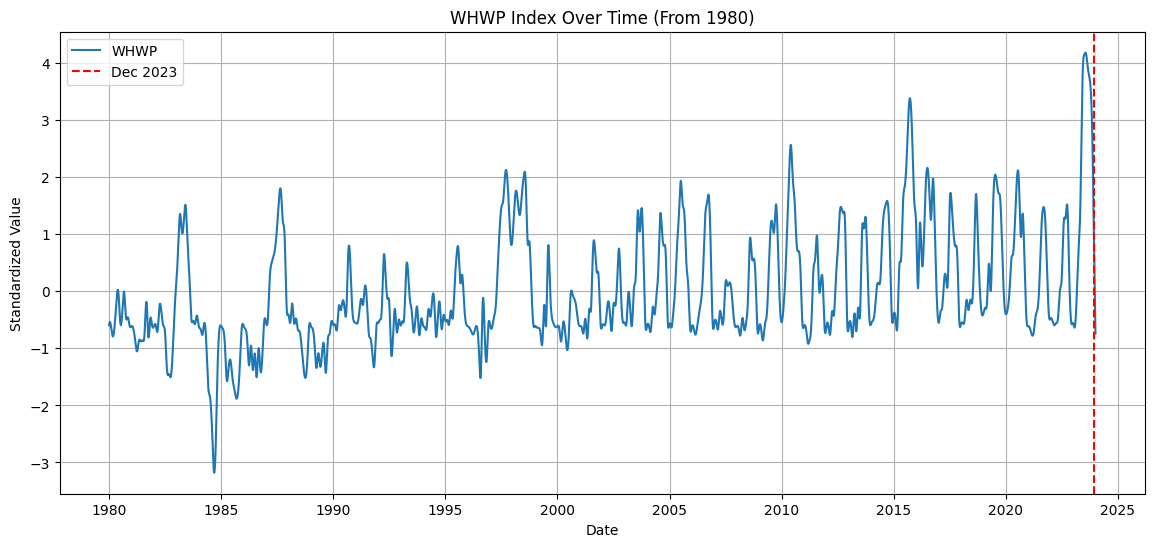

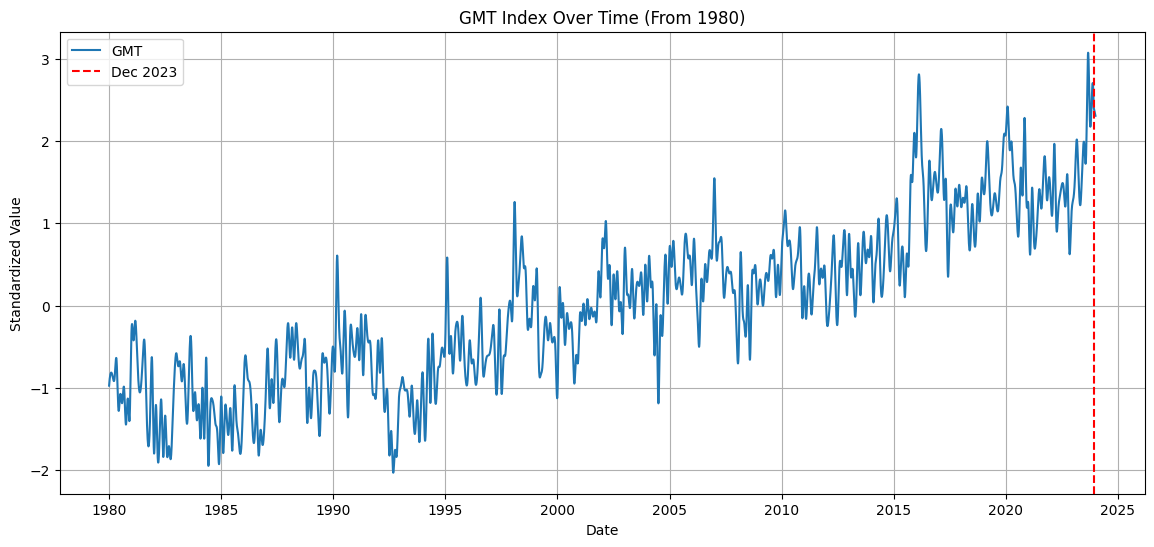

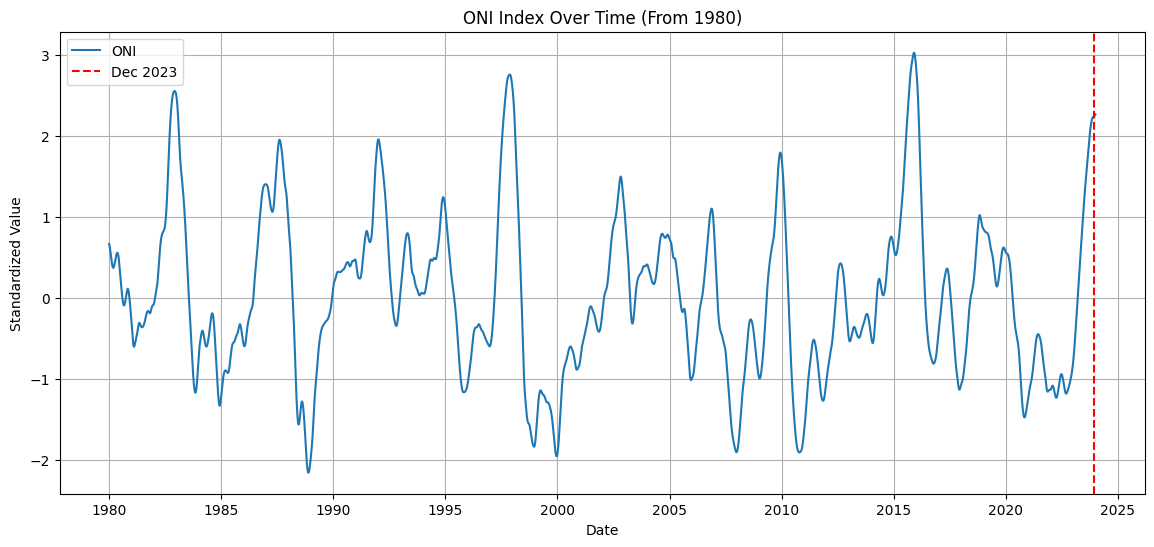

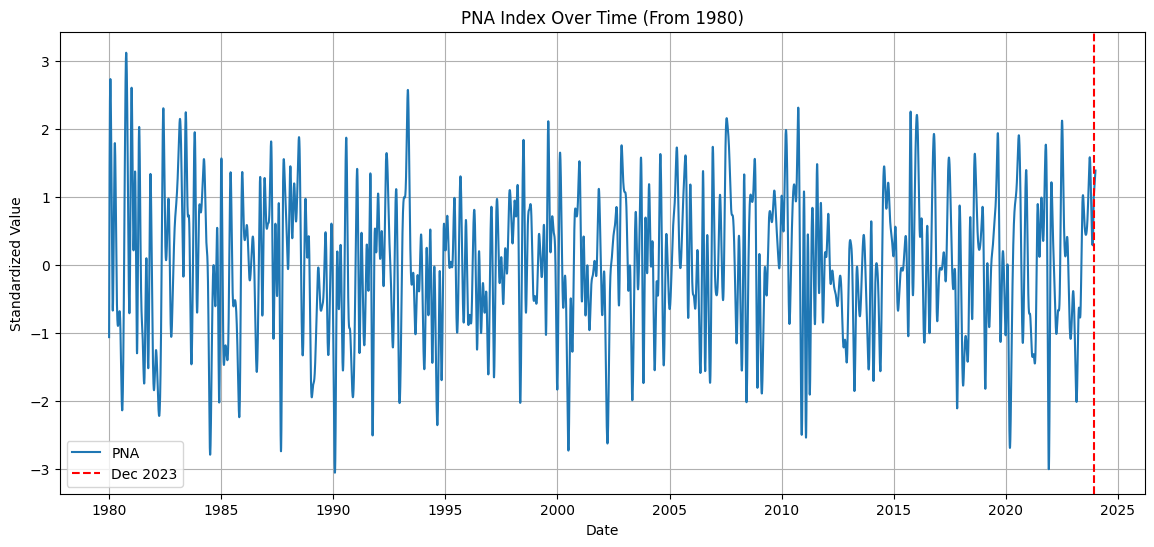

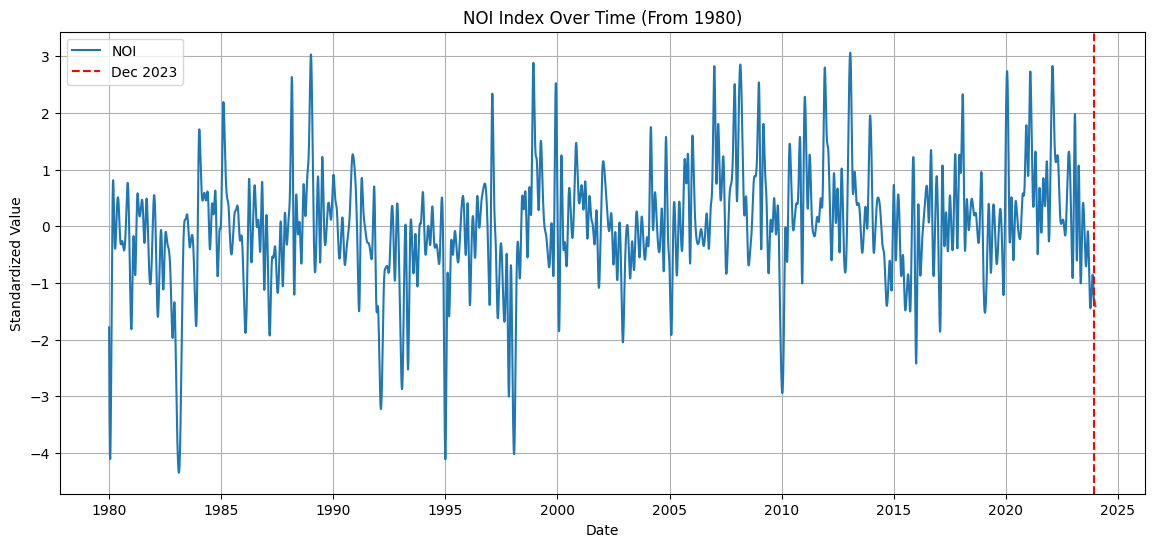

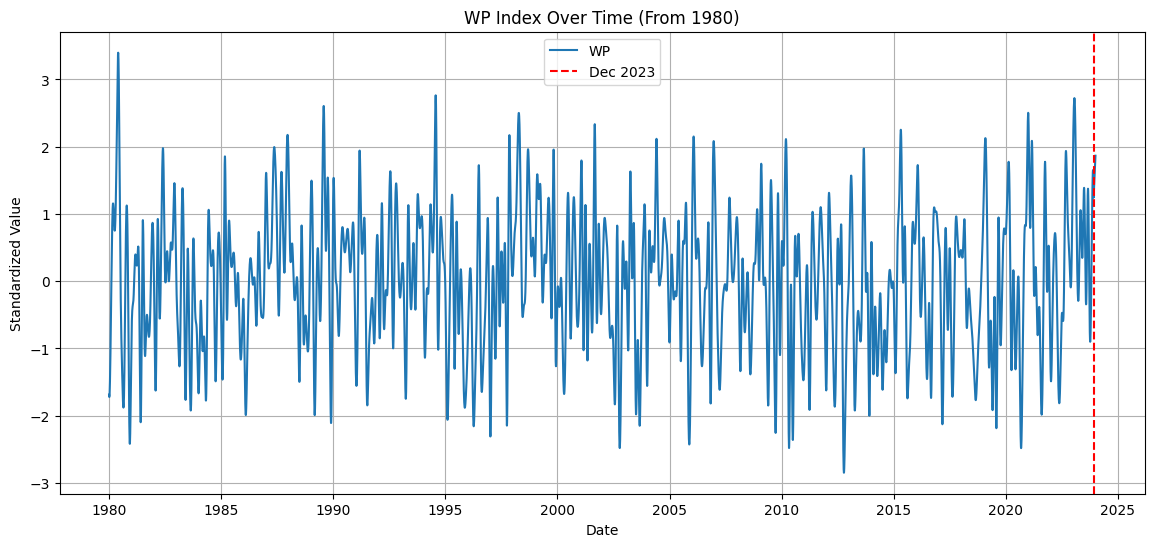

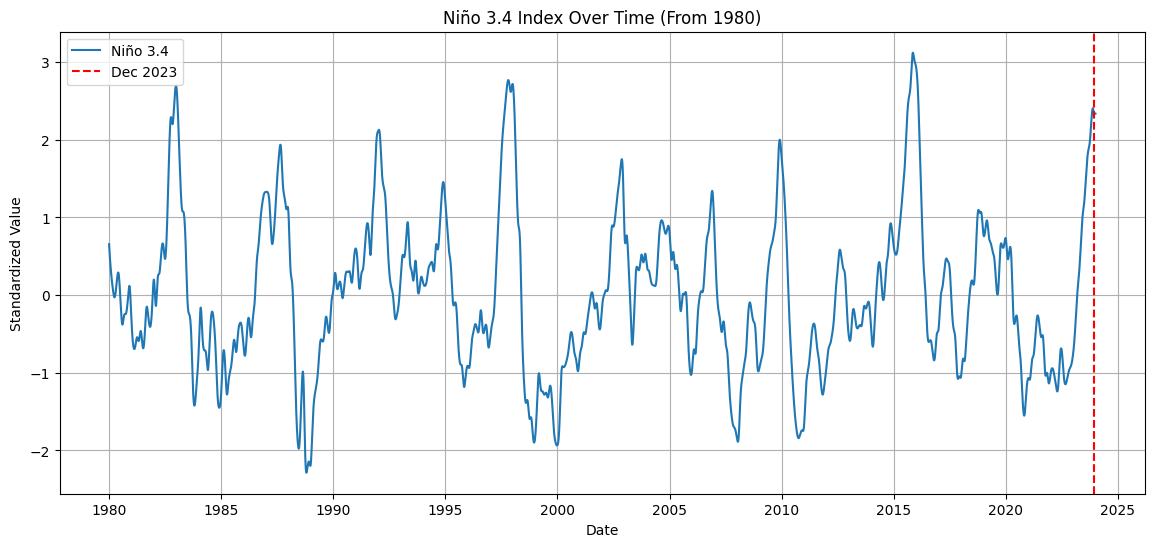

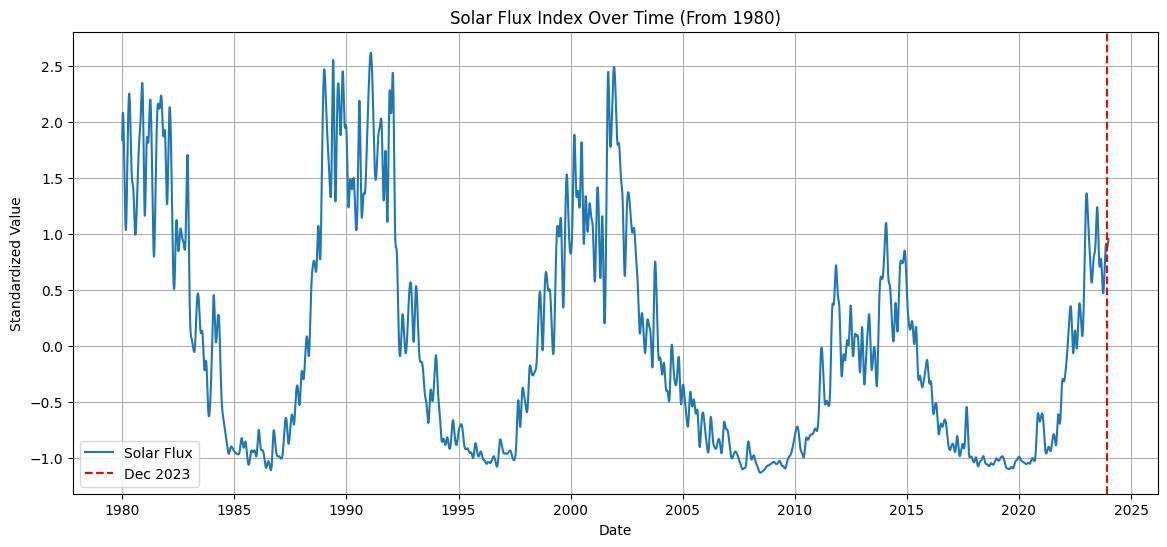

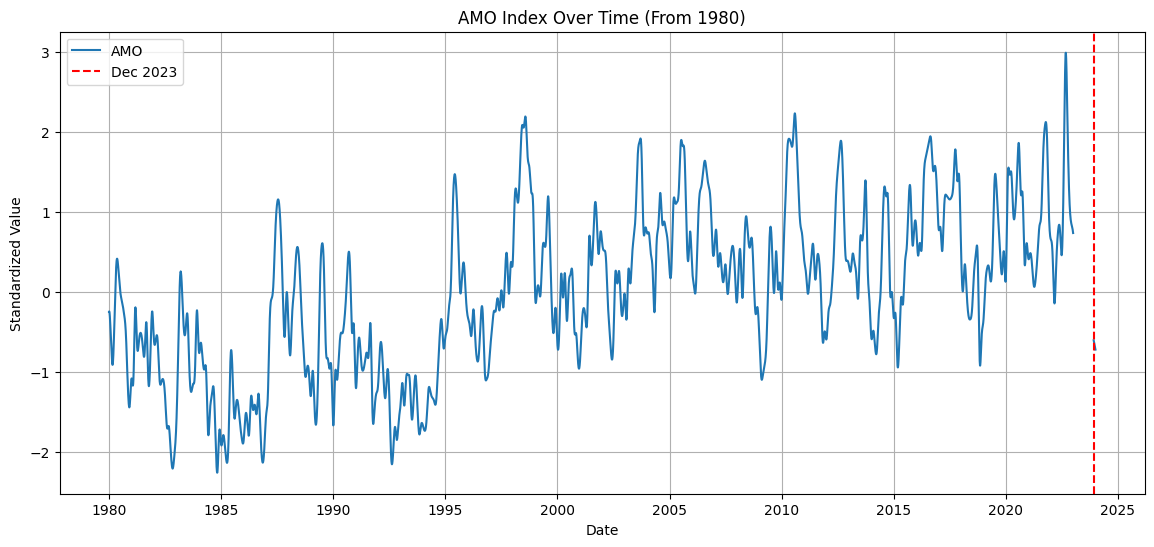

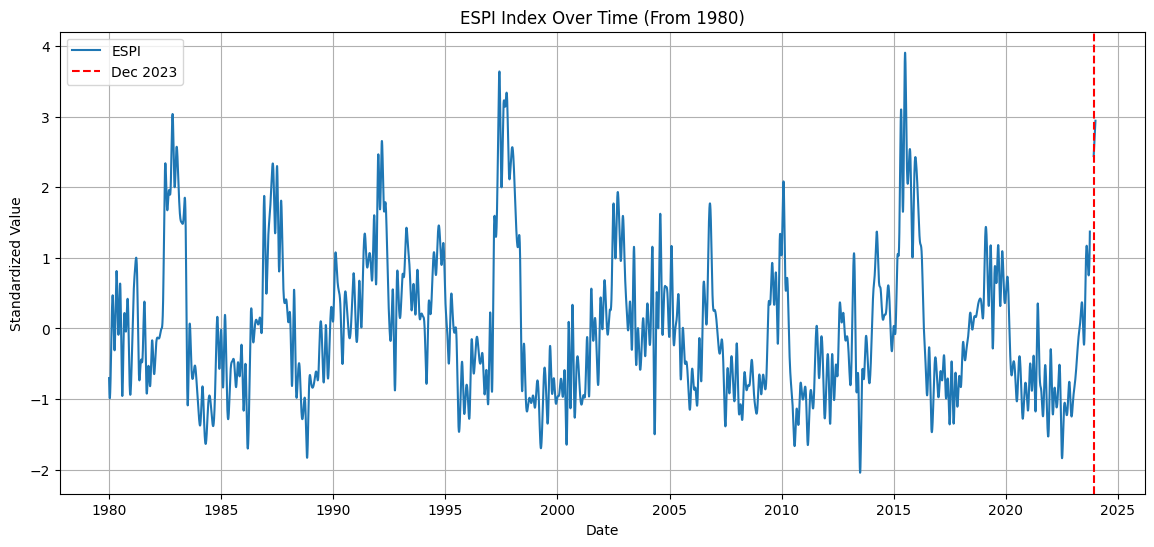

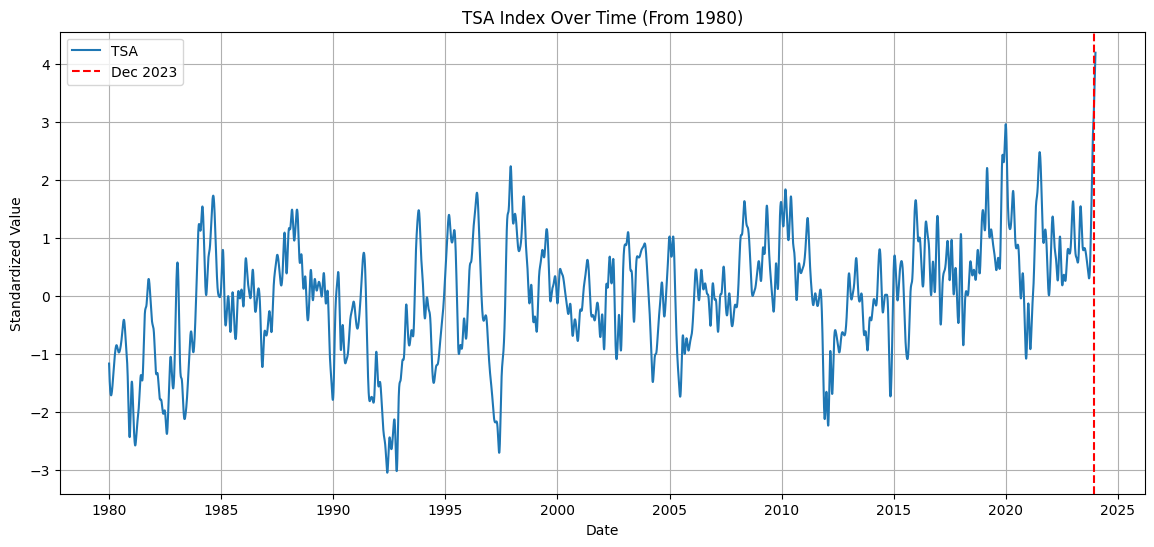

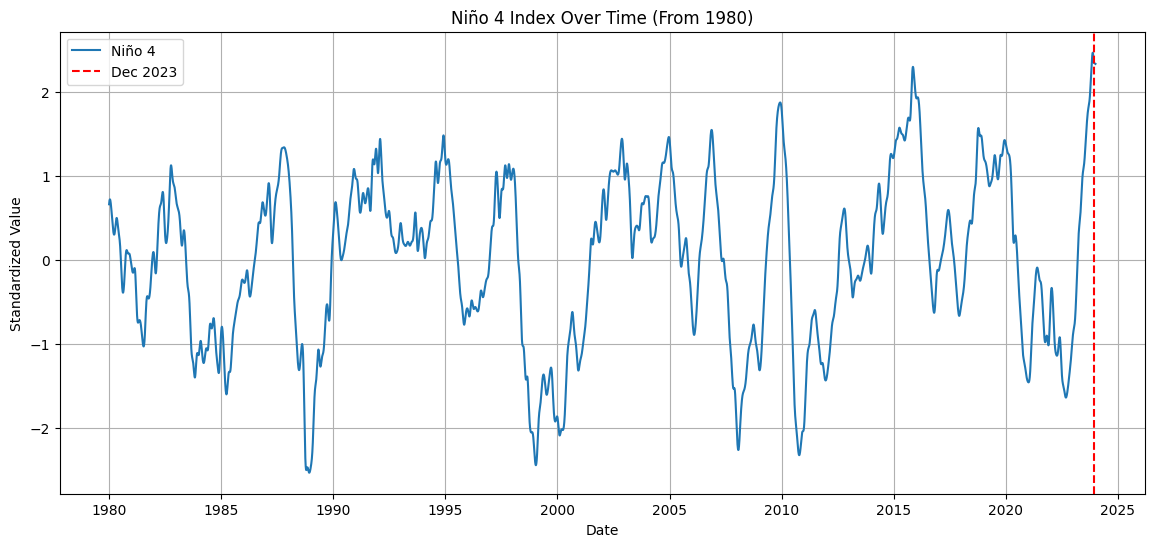

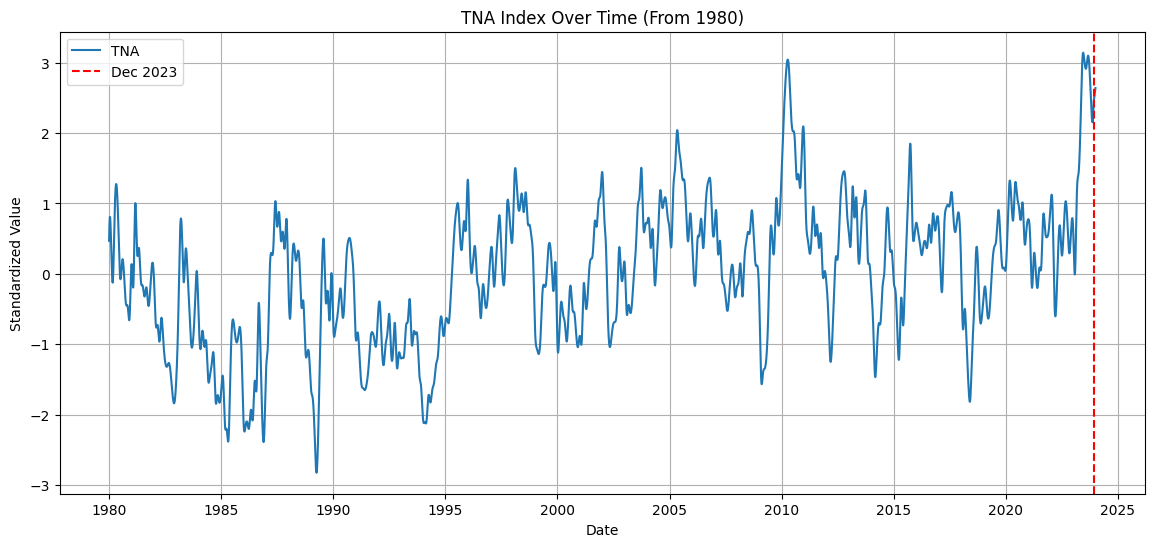

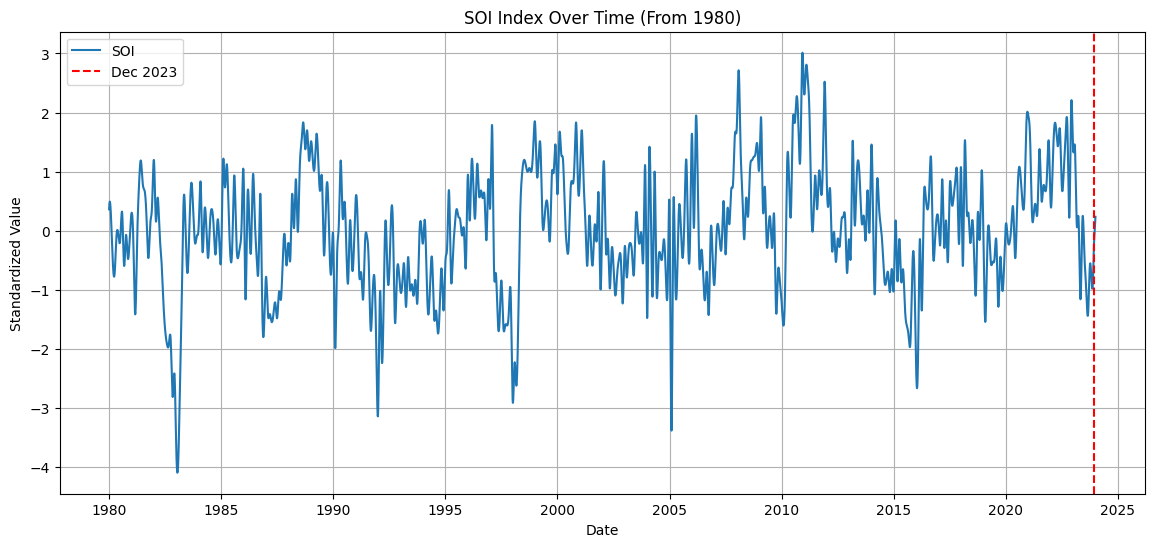

In [3]:

# Plotting each index individually
for index_name in indices_to_plot:
    if index_name in combined_data.columns:
        plt.figure(figsize=(14, 6))
        plt.plot(combined_data['Date'], combined_data[index_name], label=index_name)
        plt.axvline(x=pd.Timestamp('2023-12-01'), color='red', linestyle='--', label='Dec 2023')
        plt.title(f"{index_name} Index Over Time (From 1980)")
        plt.xlabel("Date")
        plt.ylabel("Standardized Value")
        plt.legend()
        plt.grid(True)
        plt.show()
input_dir = "/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices"

combined_data.to_csv(os.path.join(input_dir, "combined_indices_daily_standardized.csv"), index=False)


## Do the PCA for all indexes you considered before to up to Jan 31, 2023!


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


All required columns found.
PC1 plot saved to: /data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices/PC1_plot.png


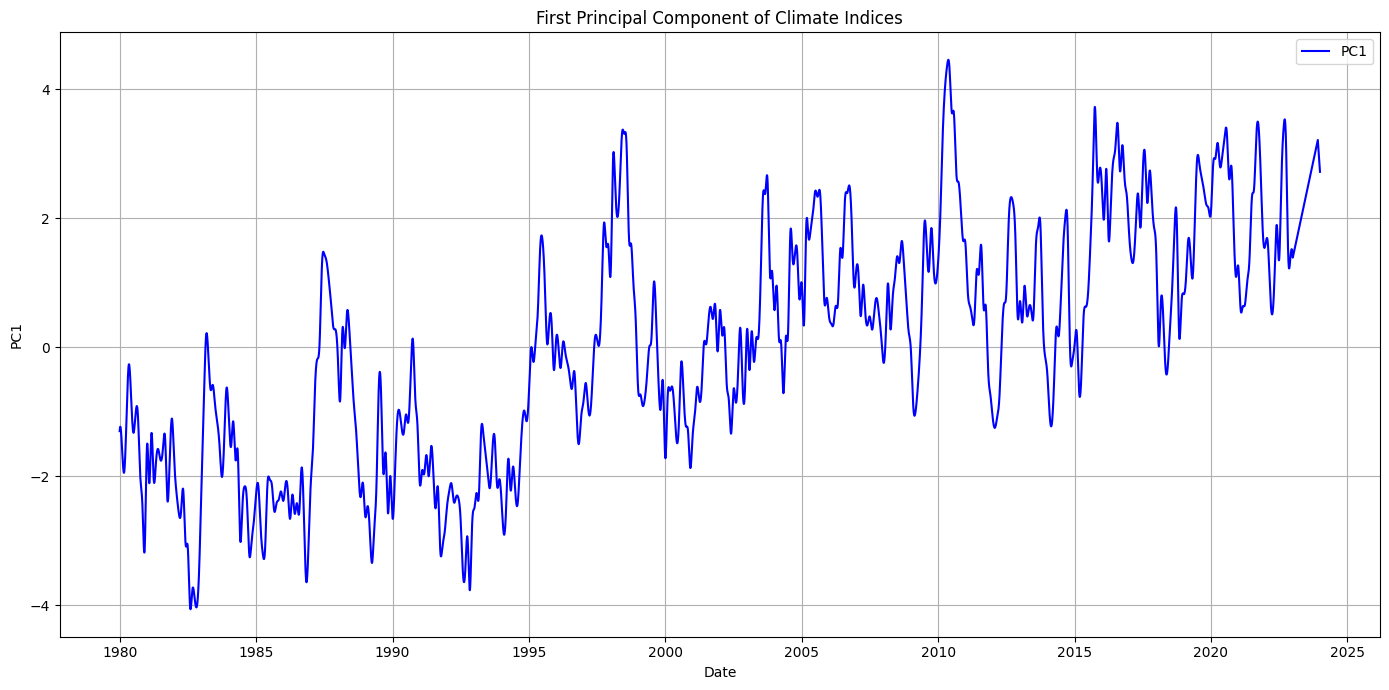

In [9]:
import os
import sys
import subprocess

# Function to install a package if it's not already installed
def install_if_missing(package):
    try:
        __import__(package)
    except ImportError:
        # Handle the special case for scikit-learn, which is imported as sklearn
        if package == "sklearn" or package == "scikit-learn":
            pkg = "scikit-learn"
        else:
            pkg = package
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

# Ensure necessary packages are installed
install_if_missing("pandas")
install_if_missing("numpy")
install_if_missing("matplotlib")
install_if_missing("scikit-learn")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Define the path to the combined CSV data
input_dir = "/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices"
csv_file = os.path.join(input_dir, "combined_indices_daily_standardized.csv")

# Read the CSV file; ensure that the 'Date' column is parsed as datetime
df = pd.read_csv(csv_file, parse_dates=['Date'])

# Define the list of indices to include in the PCA
indices = ['Solar Flux', 'ONI', 'WHWP', 'GMT', 'AMO', 'TSA', 'TNA', 'SOI']

# Check if all requested indices are present in the data
missing_cols = [col for col in indices if col not in df.columns]
if missing_cols:
    print("Warning: The following columns are missing in your data:", missing_cols)
else:
    print("All required columns found.")

# Prepare the dataframe by selecting Date and the specified indices, dropping rows with missing values
df_pca = df[['Date'] + indices].dropna()

# Extract the values for PCA as a NumPy array
X = df_pca[indices].values

# Standardize the data (z-score normalization)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Perform PCA with as many components as the number of indices
pca = PCA(n_components=len(indices))
principal_components = pca.fit_transform(X_std)

# The first principal component (PC1) is the first column of the transformation
df_pca['PC1'] = principal_components[:, 0]

# Plot the first principal component over time
plt.figure(figsize=(14, 7))
plt.plot(df_pca['Date'], df_pca['PC1'], label='PC1', color='blue')
plt.xlabel("Date")
plt.ylabel("PC1")
plt.title("First Principal Component of Climate Indices")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the plot as a PNG file in the input directory
plot_path = os.path.join(input_dir, "PC1_plot.png")
plt.savefig(plot_path)
print(f"PC1 plot saved to: {plot_path}")
plt.show()
